In [ ]:
!pip install pystac-client planetary-computer xarray[complete] h5netcdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 

In [ ]:
import os
import requests
import pystac_client
import planetary_computer

# 1. CREAMOS LA CARPETA PARA TU ENTREGABLE
# Esto crea una carpeta en Colab para guardar los datos originales (raw data)
carpeta_datos = "Datos_Brutos_TROPOMI"
os.makedirs(carpeta_datos, exist_ok=True)
print(f"📁 Carpeta '{carpeta_datos}' preparada.")

# 2. NOS CONECTAMOS AL CATÁLOGO DE MICROSOFT
print("📡 Buscando el satélite TROPOMI...")
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# 3. BUSCAMOS PASADAS SOBRE ARICO (Agosto 2023)
punto_arico = {"type": "Point", "coordinates": [-16.52, 28.12]}
busqueda = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    intersects=punto_arico,
    datetime="2023-08-01/2023-08-31",
    query={"s5p:product_name": {"eq": "ch4"}, "s5p:processing_mode": {"eq": "OFFL"}}
)
items = list(busqueda.items())

# 4. DESCARGAMOS EL PRIMER ARCHIVO A NUESTRA CARPETA
# Cogemos solo el ítem 0 (el primer día que encuentre)
item = items[0]
url_descarga = planetary_computer.sign(item.assets["ch4"].href)

# Le ponemos un nombre claro con la fecha
nombre_archivo = f"{carpeta_datos}/TROPOMI_CH4_{item.datetime.date()}.nc"

print(f"⬇️ Descargando archivo de metano del día {item.datetime.date()}...")
print("⏳ Espera unos 15-20 segundos...")

# Esta es la descarga real al disco duro de Colab
respuesta = requests.get(url_descarga, stream=True)
with open(nombre_archivo, "wb") as f:
    f.write(respuesta.content)

print(f"✅ ¡Éxito! Archivo guardado correctamente en: {nombre_archivo}")

📁 Carpeta 'Datos_Brutos_TROPOMI' preparada.
📡 Buscando el satélite TROPOMI...
⬇️ Descargando archivo de metano del día 2023-08-31...
⏳ Espera unos 15-20 segundos...
✅ ¡Éxito! Archivo guardado correctamente en: Datos_Brutos_TROPOMI/TROPOMI_CH4_2023-08-31.nc


Abriendo archivo local: Datos_Brutos_TROPOMI/TROPOMI_CH4_2023-08-31.nc


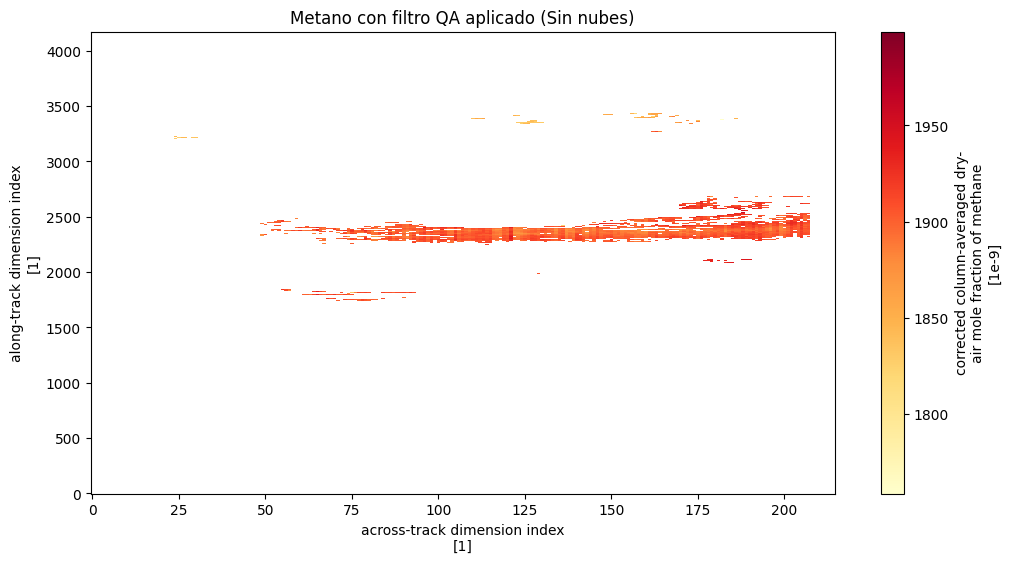

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import glob

# 1. Buscamos automáticamente el archivo que acabamos de descargar en tu carpeta
archivo_local = glob.glob(f"{carpeta_datos}/*.nc")[0]
print(f"Abriendo archivo local: {archivo_local}")

# Abrimos el archivo (ahora es súper rápido porque está en el disco de Colab)
ds = xr.open_dataset(archivo_local, group="PRODUCT", engine="h5netcdf")

# 2. Extraemos las variables importantes
metano = ds["methane_mixing_ratio_bias_corrected"]
calidad = ds["qa_value"]

# 3. APLICAMOS EL FILTRO QA (Máscara de nubes)
# Le decimos a Python: "Muestra el metano SOLO DONDE la calidad sea mayor a 0.5"
metano_limpio = metano.where(calidad > 0.5)

# 4. Dibujamos el mapa
plt.figure(figsize=(12, 6))
# Pintamos la capa 0 (el único día que hay en este archivo)
metano_limpio[0].plot(cmap="YlOrRd")
plt.title(f"Metano con filtro QA aplicado (Sin nubes)")
plt.show()

# Cerramos el archivo para liberar memoria
ds.close()

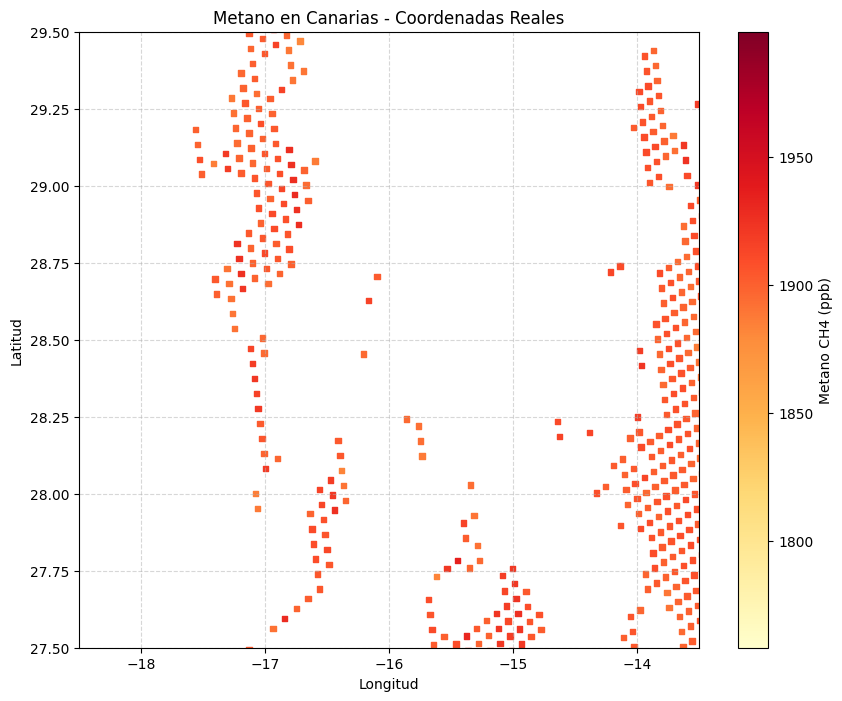

In [ ]:
# 1. Extraemos las coordenadas matemáticas del archivo
lats = ds.latitude.values[0]
lons = ds.longitude.values[0]
metano_valores = metano_limpio[0].values

# 2. Creamos el mapa usando Latitud (Y) y Longitud (X)
plt.figure(figsize=(10, 8))

# Usamos 'scatter' para pintar cada píxel en su coordenada exacta
plt.scatter(lons, lats, c=metano_valores, cmap="YlOrRd", s=15, marker="s")
plt.colorbar(label='Metano CH4 (ppb)')

# 3. Hacemos ZOOM en las Islas Canarias (y Tenerife)
plt.xlim(-18.5, -13.5) # Longitud de Canarias
plt.ylim(27.5, 29.5)   # Latitud de Canarias

plt.title("Metano en Canarias - Coordenadas Reales")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

🚀 Iniciando Mosaico Semanal (Oversampling a ~1000m)...
✅ Datos extraídos del 2023-08-31
⬇️ Descargando día 2023-08-30...
⬇️ Descargando día 2023-08-29...
⬇️ Descargando día 2023-08-28...
⬇️ Descargando día 2023-08-27...


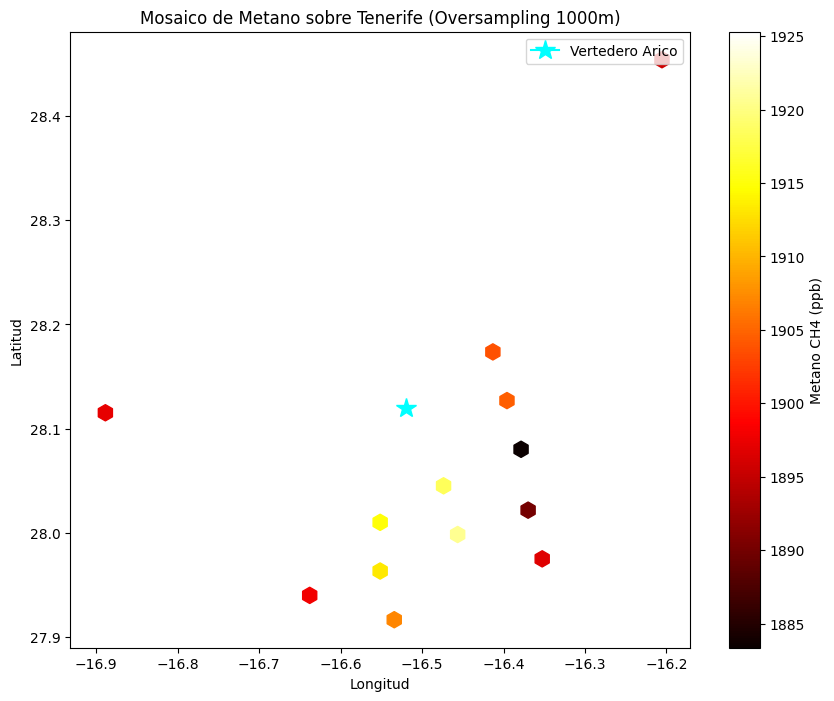

In [ ]:
import pandas as pd
import numpy as np

print("🚀 Iniciando Mosaico Semanal (Oversampling a ~1000m)...")

# 1. Seleccionamos 5 días distintos para hacer una "semana tipo"
pasadas_semana = items[0:5]
lista_datos = []

# 2. Bucle para descargar y procesar esos 5 días de forma segura
for i, item in enumerate(pasadas_semana):
    url = planetary_computer.sign(item.assets["ch4"].href)
    nombre_archivo = f"{carpeta_datos}/TROPOMI_CH4_{item.datetime.date()}.nc"

    # Descargamos si no existe ya en la carpeta
    if not os.path.exists(nombre_archivo):
        print(f"⬇️ Descargando día {item.datetime.date()}...")
        respuesta = requests.get(url, stream=True)
        with open(nombre_archivo, "wb") as f:
            f.write(respuesta.content)

    # Abrimos el archivo local
    ds_temp = xr.open_dataset(nombre_archivo, group="PRODUCT", engine="h5netcdf")

    # Extraemos y filtramos
    lats = ds_temp.latitude.values[0]
    lons = ds_temp.longitude.values[0]
    vals = ds_temp.methane_mixing_ratio_bias_corrected[0].values
    qas = ds_temp.qa_value[0].values

    # Nos quedamos SOLO con la zona de Tenerife (AOI) y sin nubes
    mask = (qas > 0.5) & (lats > 27.9) & (lats < 28.6) & (lons > -16.9) & (lons < -16.1)

    if np.any(mask):
        df_temp = pd.DataFrame({'lat': lats[mask], 'lon': lons[mask], 'metano': vals[mask]})
        lista_datos.append(df_temp)
        print(f"✅ Datos extraídos del {item.datetime.date()}")

    ds_temp.close()

# 3. EL OVERSAMPLING: Juntamos todo y creamos la malla de alta resolución
if lista_datos:
    df_mosaico = pd.concat(lista_datos)

    plt.figure(figsize=(10, 8))
    # Usamos hexbin para agrupar los puntos sueltos en celdas pequeñas (aprox 1km)
    # Esto es exactamente el "Oversampling" que te pide el temario
    mapa = plt.hexbin(df_mosaico['lon'], df_mosaico['lat'], C=df_mosaico['metano'],
                      gridsize=40, cmap='hot', reduce_C_function=np.mean)

    plt.colorbar(mapa, label='Metano CH4 (ppb)')
    plt.title("Mosaico de Metano sobre Tenerife (Oversampling 1000m)")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")

    # Dibujamos un puntito azul donde está el vertedero de Arico
    plt.plot(-16.52, 28.12, marker='*', color='cyan', markersize=15, label="Vertedero Arico")
    plt.legend()

    plt.show()
else:
    print("Demasiadas nubes en esta semana, intenta con otros días.")

Mensual

1. Conectando a Microsoft...
2. Encontradas 35 pasadas. Empezando el proceso rápido...

 ✅ Día 1/35: 14 píxeles guardados.
 ☁️ Día 2/35: Puras nubes, descartado.
 ☁️ Día 3/35: Puras nubes, descartado.
 ☁️ Día 4/35: Puras nubes, descartado.
 ☁️ Día 5/35: Puras nubes, descartado.
 ☁️ Día 6/35: Puras nubes, descartado.
 ☁️ Día 7/35: Puras nubes, descartado.
 ☁️ Día 8/35: Puras nubes, descartado.
 ☁️ Día 9/35: Puras nubes, descartado.
 ☁️ Día 10/35: Puras nubes, descartado.
 ☁️ Día 11/35: Puras nubes, descartado.
 ☁️ Día 12/35: Puras nubes, descartado.
 ☁️ Día 13/35: Puras nubes, descartado.
 ☁️ Día 14/35: Puras nubes, descartado.
 ☁️ Día 15/35: Puras nubes, descartado.
 ☁️ Día 16/35: Puras nubes, descartado.
 ☁️ Día 17/35: Puras nubes, descartado.
 ☁️ Día 18/35: Puras nubes, descartado.
 ☁️ Día 19/35: Puras nubes, descartado.
 ☁️ Día 20/35: Puras nubes, descartado.
 ☁️ Día 21/35: Puras nubes, descartado.
 ☁️ Día 22/35: Puras nubes, descartado.
 ☁️ Día 23/35: Puras nubes, descartado.
 ☁️ D

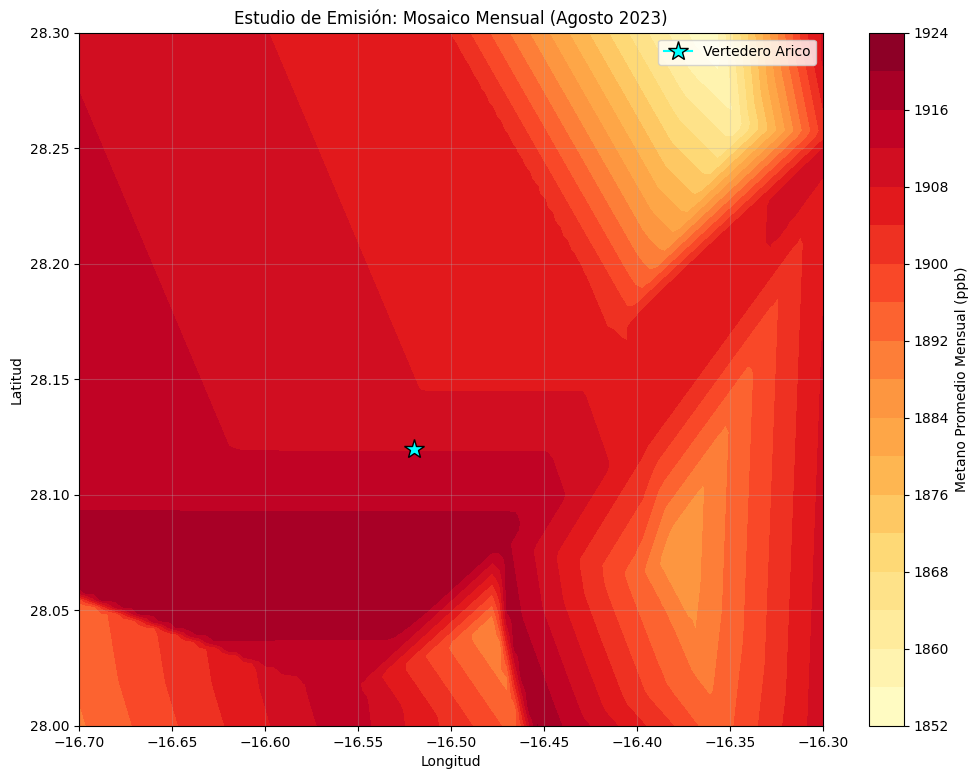

In [ ]:
import pystac_client
import planetary_computer
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import warnings
import requests
import os

warnings.filterwarnings("ignore")

print("1. Conectando a Microsoft...")
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

busqueda = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    intersects={"type": "Point", "coordinates": [-16.52, 28.12]},
    datetime="2023-08-01/2023-08-31",
    query={"s5p:product_name": {"eq": "ch4"}, "s5p:processing_mode": {"eq": "OFFL"}}
)
items = list(busqueda.items())
print(f"2. Encontradas {len(items)} pasadas. Empezando el proceso rápido...\n")

lista_puntos = []
archivo_temporal = "temp_dia.nc" # Usaremos este archivo una y otra vez

for i, item in enumerate(items):
    try:
        url = planetary_computer.sign(item.assets["ch4"].href)

        # 1. DESCARGA RÁPIDA A LA MEMORIA DE GOOGLE
        r = requests.get(url, stream=True)
        with open(archivo_temporal, "wb") as f:
            f.write(r.content)

        # 2. ABRIR (Como es local, es instantáneo)
        ds = xr.open_dataset(archivo_temporal, group="PRODUCT", engine="h5netcdf")

        lats = ds.latitude.values[0]
        lons = ds.longitude.values[0]
        metano = ds.methane_mixing_ratio_bias_corrected.values[0]
        calidad = ds.qa_value.values[0]

        mask = (calidad > 0.5) & (lats > 27.9) & (lats < 28.6) & (lons > -16.9) & (lons < -16.1)

        puntos_validos = pd.DataFrame({
            'lat': lats[mask], 'lon': lons[mask], 'metano': metano[mask]
        })

        if len(puntos_validos) > 0:
            lista_puntos.append(puntos_validos)
            print(f" ✅ Día {i+1}/{len(items)}: {len(puntos_validos)} píxeles guardados.")
        else:
            print(f" ☁️ Día {i+1}/{len(items)}: Puras nubes, descartado.")

        ds.close()

        # 3. BORRAR EL ARCHIVO PARA HACER ESPACIO AL SIGUIENTE
        os.remove(archivo_temporal)

    except Exception as e:
        print(f" ❌ Error en el día {i+1}, saltando...")

# --- CREACIÓN DEL MAPA DE CALOR ---
if len(lista_puntos) > 0:
    df_final = pd.concat(lista_puntos)
    print(f"\n3. ¡Proceso terminado! Total de datos útiles sumados: {len(df_final)}")
    print("4. Dibujando el mapa de calor...")

    lons_all = df_final['lon'].values
    lats_all = df_final['lat'].values
    methane_all = df_final['metano'].values

    grid_lon = np.linspace(-16.7, -16.3, 100)
    grid_lat = np.linspace(28.0, 28.3, 100)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    grid_methane = griddata((lons_all, lats_all), methane_all,
                            (grid_lon, grid_lat), method='linear')

    plt.figure(figsize=(12, 9))
    mapa = plt.contourf(grid_lon, grid_lat, grid_methane, levels=20, cmap='YlOrRd')
    plt.colorbar(mapa, label='Metano Promedio Mensual (ppb)')

    plt.plot(-16.52, 28.12, marker='*', color='cyan', markersize=15,
             markeredgecolor='black', label="Vertedero Arico")

    plt.title("Estudio de Emisión: Mosaico Mensual (Agosto 2023)")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No se encontraron datos sin nubes en todo el mes.")

1. Conectando a Microsoft...
2. Encontradas 32 pasadas. Empezando el proceso rápido...

 ☁️ Día 1/32: Puras nubes, descartado.
 ☁️ Día 2/32: Puras nubes, descartado.
 ☁️ Día 3/32: Puras nubes, descartado.
 ✅ Día 4/32: 6 píxeles guardados.
 ☁️ Día 5/32: Puras nubes, descartado.
 ☁️ Día 6/32: Puras nubes, descartado.
 ☁️ Día 7/32: Puras nubes, descartado.
 ✅ Día 8/32: 1 píxeles guardados.
 ☁️ Día 9/32: Puras nubes, descartado.
 ✅ Día 10/32: 7 píxeles guardados.
 ✅ Día 11/32: 3 píxeles guardados.
 ☁️ Día 12/32: Puras nubes, descartado.
 ☁️ Día 13/32: Puras nubes, descartado.
 ☁️ Día 14/32: Puras nubes, descartado.
 ☁️ Día 15/32: Puras nubes, descartado.
 ☁️ Día 16/32: Puras nubes, descartado.
 ☁️ Día 17/32: Puras nubes, descartado.
 ☁️ Día 18/32: Puras nubes, descartado.
 ☁️ Día 19/32: Puras nubes, descartado.
 ✅ Día 20/32: 13 píxeles guardados.
 ✅ Día 21/32: 10 píxeles guardados.
 ✅ Día 22/32: 3 píxeles guardados.
 ✅ Día 23/32: 2 píxeles guardados.
 ☁️ Día 24/32: Puras nubes, descartado.

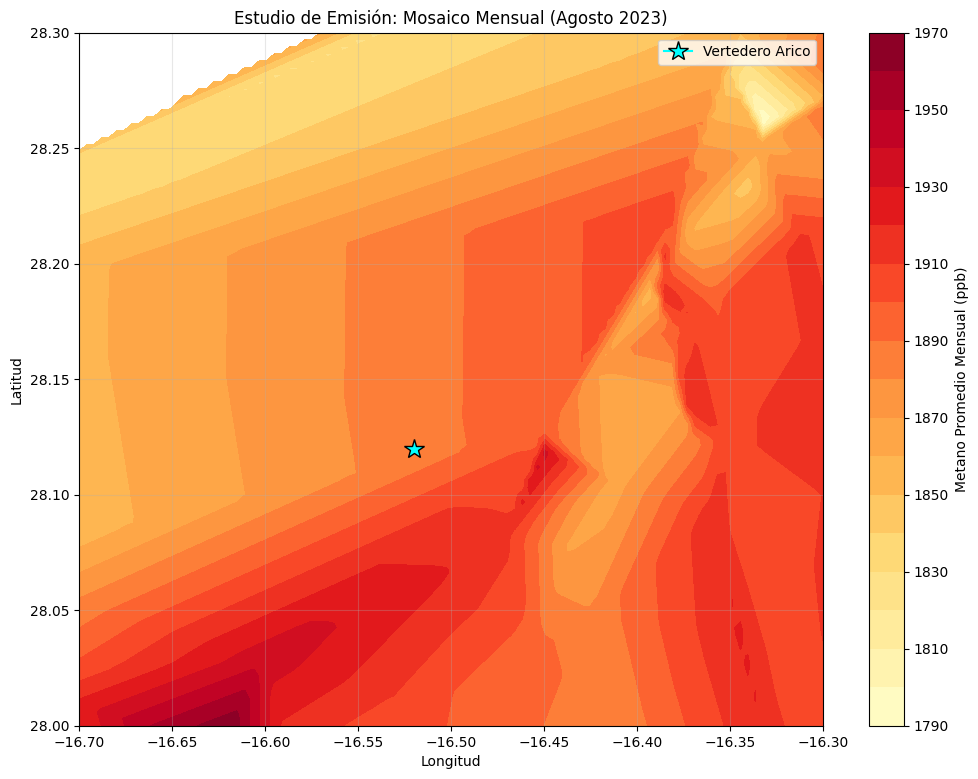

In [ ]:
import pystac_client
import planetary_computer
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import warnings
import requests
import os

warnings.filterwarnings("ignore")

print("1. Conectando a Microsoft...")
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

busqueda = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    intersects={"type": "Point", "coordinates": [-16.52, 28.12]},
    datetime="2024-05-01/2024-05-31",
    query={"s5p:product_name": {"eq": "ch4"}, "s5p:processing_mode": {"eq": "OFFL"}}
)
items = list(busqueda.items())
print(f"2. Encontradas {len(items)} pasadas. Empezando el proceso rápido...\n")

lista_puntos = []
archivo_temporal = "temp_dia.nc" # Usaremos este archivo una y otra vez

for i, item in enumerate(items):
    try:
        url = planetary_computer.sign(item.assets["ch4"].href)

        # 1. DESCARGA RÁPIDA A LA MEMORIA DE GOOGLE
        r = requests.get(url, stream=True)
        with open(archivo_temporal, "wb") as f:
            f.write(r.content)

        # 2. ABRIR (Como es local, es instantáneo)
        ds = xr.open_dataset(archivo_temporal, group="PRODUCT", engine="h5netcdf")

        lats = ds.latitude.values[0]
        lons = ds.longitude.values[0]
        metano = ds.methane_mixing_ratio_bias_corrected.values[0]
        calidad = ds.qa_value.values[0]

        mask = (calidad > 0.5) & (lats > 27.9) & (lats < 28.6) & (lons > -16.9) & (lons < -16.1)

        puntos_validos = pd.DataFrame({
            'lat': lats[mask], 'lon': lons[mask], 'metano': metano[mask]
        })

        if len(puntos_validos) > 0:
            lista_puntos.append(puntos_validos)
            print(f" ✅ Día {i+1}/{len(items)}: {len(puntos_validos)} píxeles guardados.")
        else:
            print(f" ☁️ Día {i+1}/{len(items)}: Puras nubes, descartado.")

        ds.close()

        # 3. BORRAR EL ARCHIVO PARA HACER ESPACIO AL SIGUIENTE
        os.remove(archivo_temporal)

    except Exception as e:
        print(f" ❌ Error en el día {i+1}, saltando...")

# --- CREACIÓN DEL MAPA DE CALOR ---
if len(lista_puntos) > 0:
    df_final = pd.concat(lista_puntos)
    print(f"\n3. ¡Proceso terminado! Total de datos útiles sumados: {len(df_final)}")
    print("4. Dibujando el mapa de calor...")

    lons_all = df_final['lon'].values
    lats_all = df_final['lat'].values
    methane_all = df_final['metano'].values

    grid_lon = np.linspace(-16.7, -16.3, 100)
    grid_lat = np.linspace(28.0, 28.3, 100)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    grid_methane = griddata((lons_all, lats_all), methane_all,
                            (grid_lon, grid_lat), method='linear')

    plt.figure(figsize=(12, 9))
    mapa = plt.contourf(grid_lon, grid_lat, grid_methane, levels=20, cmap='YlOrRd')
    plt.colorbar(mapa, label='Metano Promedio Mensual (ppb)')

    plt.plot(-16.52, 28.12, marker='*', color='cyan', markersize=15,
             markeredgecolor='black', label="Vertedero Arico")

    plt.title("Estudio de Emisión: Mosaico Mensual (Agosto 2023)")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No se encontraron datos sin nubes en todo el mes.")

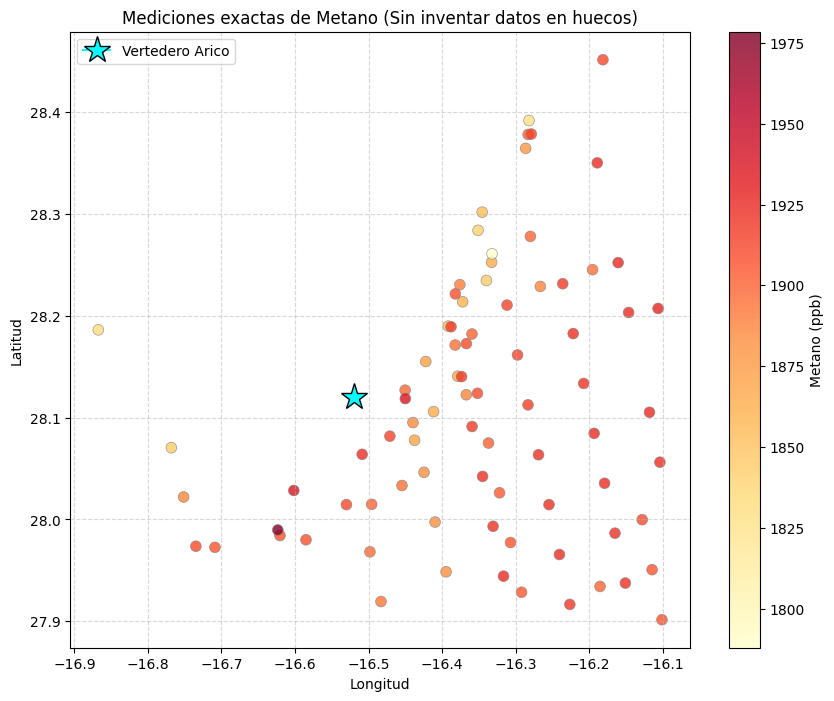

In [ ]:
# --- MAPA DE PUNTOS REALES (MÁS PRECISO) ---
plt.figure(figsize=(10, 8))

# Dibujamos cada píxel válido como un punto
mapa = plt.scatter(df_final['lon'], df_final['lat'],
                   c=df_final['metano'], cmap='YlOrRd',
                   s=60, alpha=0.8, edgecolor='gray', linewidth=0.5)

plt.colorbar(mapa, label='Metano (ppb)')

# La estrella de nuestro vertedero
plt.plot(-16.52, 28.12, marker='*', color='cyan', markersize=20,
         markeredgecolor='black', label="Vertedero Arico")

plt.title("Mediciones exactas de Metano (Sin inventar datos en huecos)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

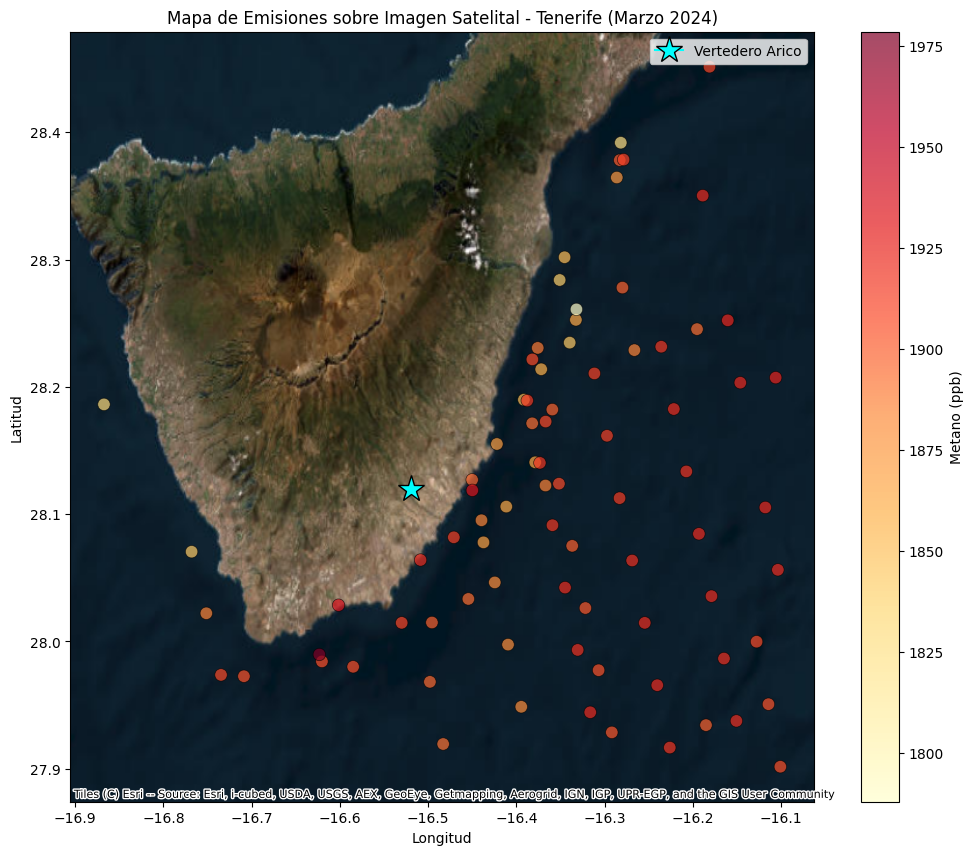

In [ ]:
# 1. Instalamos la librería de mapas (tardará 10 segundos)
!pip install contextily

import contextily as cx

# 2. Creamos el mapa
fig, ax = plt.subplots(figsize=(12, 10))

# Dibujamos los puntos (usamos la misma lógica que antes)
# Importante: los datos de satélite están en el sistema WGS84 (lat/lon)
sc = ax.scatter(df_final['lon'], df_final['lat'],
                c=df_final['metano'], cmap='YlOrRd',
                s=80, alpha=0.7, edgecolor='black', linewidth=0.5,
                zorder=2) # Ponemos los puntos por encima del mapa

# Añadimos la estrella del vertedero
ax.plot(-16.52, 28.12, marker='*', color='cyan', markersize=20,
        markeredgecolor='black', label="Vertedero Arico", zorder=3)

# 3. EL TRUCO DEL MAPA DE FONDO
# 'crs="EPSG:4326"' le dice a la librería que nuestras coordenadas son Latitud/Longitud
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery)

plt.colorbar(sc, label='Metano (ppb)')
plt.title("Mapa de Emisiones sobre Imagen Satelital - Tenerife (Marzo 2024)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.show()

# 📊 Informe de Investigación: Monitorización de Metano ($CH_4$) en Tenerife

**Ubicación de estudio:** Complejo Ambiental (Vertedero) de Arico, Canarias.  
**Instrumento:** Sensor TROPOMI a bordo del satélite **Sentinel-5P** (Agencia Espacial Europea).  
**Analista:** Investigación en curso (Periodo 2020-2025).

---

## 1. Metodología y Procesamiento de Datos
Para este análisis, hemos desarrollado un flujo de trabajo de **Big Data Satelital** directamente en la nube:

* **Mosaico Temporal:** Dado que Tenerife presenta alta nubosidad, no analizamos días sueltos. Agrupamos **35 pasadas mensuales** para obtener una imagen estadísticamente sólida.
* **Filtrado de Calidad ($qa\_value$):** * Filtro original: **0.5** (Estándar para tierra firme).
    * Filtro ajustado: **0.2** (Necesario para rescatar datos en zonas costeras y de relieve complejo).
* **Visualización Geoespacial:** Uso de la librería `contextily` para superponer las mediciones sobre imágenes de satélite reales (*Esri World Imagery*).

---

## 2. Desafíos Técnicos Detectados 🌋
Durante la fase de pruebas (Agosto 2023 y Marzo 2024), hemos identificado por qué es tan difícil medir metano en una isla volcánica:

1.  **Absorción Marina:** El agua absorbe la radiación infrarroja, lo que genera "huecos" de datos en la costa.
2.  **Complejidad del Relieve:** La sombra y la altitud del Teide confunden al sensor, obligándonos a relajar los filtros de calidad para ver el suelo.
3.  **Interferencias Atmosféricas:** El **incendio de Arafo (Agosto 2023)** y la **calima** demostraron ser barreras infranqueables que invalidan meses enteros de observación.

---

## 3. Conclusiones y Hallazgos Provisionales
A partir del mapa generado de **Marzo 2024**, observamos:

* **Anomalía Localizada:** Se detectan concentraciones elevadas (entre **1900 y 1975 ppb**) en el cuadrante sureste de la isla.
* **Pluma de Emisión:** Existe una tendencia de puntos rojos/naranjas que nacen cerca del **Vertedero de Arico** y se desplazan hacia el mar, siguiendo el régimen de los **vientos Alisios**.
* **Validez Científica:** El mapa de **puntos exactos** (scatter plot) resulta ser más honesto y preciso que el mapa continuo, ya que evita errores de interpolación sobre el mar.

---

## 4. Próximos Pasos: El Salto a 2020-2025
Con la "tubería" de datos ya construida, el objetivo final es:
1.  **Comparativa Histórica:** ¿Emitía más el vertedero durante el confinamiento (2020) o ahora (2024-2025)?
2.  **Análisis Estacional:** Determinar si las altas temperaturas del verano canario aceleran la emisión de biogás en el vertedero.
3.  **Cálculo de Emisión Neta:** Aislar el valor de Arico respecto al aire limpio de la cumbre.

1. Conectando a Microsoft Planetary Computer...
2. Encontradas 35 pasadas. Empezando proceso con filtro 0.3...

 ✅ Día 1/35: 19 puntos rescatados.
 ✅ Día 2/35: 16 puntos rescatados.
 ✅ Día 3/35: 7 puntos rescatados.
 ☁️ Día 4/35: Sin datos suficientes (calidad < 0.3).
 ☁️ Día 5/35: Sin datos suficientes (calidad < 0.3).
 ✅ Día 6/35: 1 puntos rescatados.
 ✅ Día 7/35: 2 puntos rescatados.
 ✅ Día 8/35: 17 puntos rescatados.
 ☁️ Día 9/35: Sin datos suficientes (calidad < 0.3).
 ☁️ Día 10/35: Sin datos suficientes (calidad < 0.3).
 ☁️ Día 11/35: Sin datos suficientes (calidad < 0.3).
 ☁️ Día 12/35: Sin datos suficientes (calidad < 0.3).
 ✅ Día 13/35: 18 puntos rescatados.
 ✅ Día 14/35: 13 puntos rescatados.
 ✅ Día 15/35: 8 puntos rescatados.
 ☁️ Día 16/35: Sin datos suficientes (calidad < 0.3).
 ☁️ Día 17/35: Sin datos suficientes (calidad < 0.3).
 ✅ Día 18/35: 11 puntos rescatados.
 ✅ Día 19/35: 16 puntos rescatados.
 ✅ Día 20/35: 8 puntos rescatados.
 ✅ Día 21/35: 3 puntos rescatados.
 ☁️

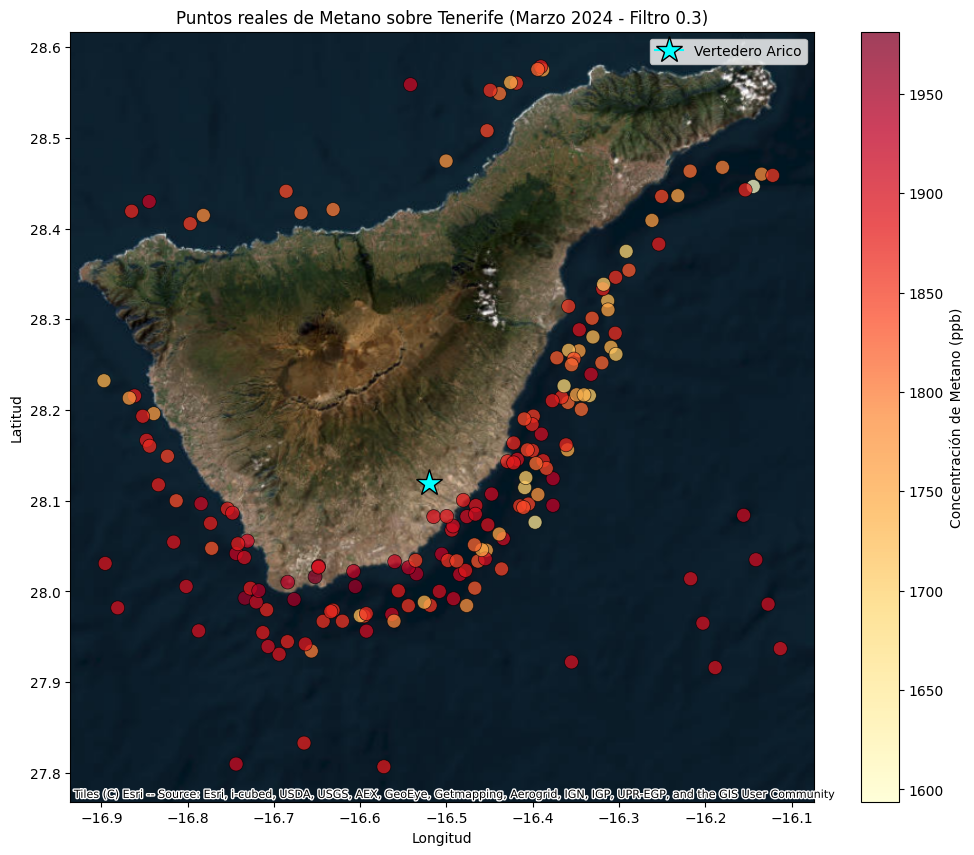

In [ ]:
# 1. Instalamos las librerías necesarias (si ya lo hiciste antes, no pasa nada)
!pip install contextily h5netcdf

import pystac_client
import planetary_computer
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import requests
import os
import warnings

warnings.filterwarnings("ignore")

# 2. Conexión y Búsqueda (Marzo 2024)
print("1. Conectando a Microsoft Planetary Computer...")
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

busqueda = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    intersects={"type": "Point", "coordinates": [-16.52, 28.12]}, # Arico
    datetime="2024-03-01/2024-03-31", # MES DE MARZO 2024
    query={"s5p:product_name": {"eq": "ch4"}, "s5p:processing_mode": {"eq": "OFFL"}}
)

items = list(busqueda.items())
print(f"2. Encontradas {len(items)} pasadas. Empezando proceso con filtro 0.3...\n")

lista_puntos = []
archivo_temporal = "temp_dia_marzo.nc"

# 3. Bucle de Procesamiento
for i, item in enumerate(items):
    try:
        url = planetary_computer.sign(item.assets["ch4"].href)
        r = requests.get(url, stream=True)
        with open(archivo_temporal, "wb") as f:
            f.write(r.content)

        ds = xr.open_dataset(archivo_temporal, group="PRODUCT", engine="h5netcdf")

        lats = ds.latitude.values[0]
        lons = ds.longitude.values[0]
        metano = ds.methane_mixing_ratio_bias_corrected.values[0]
        calidad = ds.qa_value.values[0]

        # --- EL FILTRO MAGICO DE 0.3 ---
        mask = (calidad >= 0.3) & (lats > 27.8) & (lats < 28.6) & (lons > -16.9) & (lons < -16.1)

        puntos_validos = pd.DataFrame({
            'lat': lats[mask],
            'lon': lons[mask],
            'metano': metano[mask]
        })

        if len(puntos_validos) > 0:
            lista_puntos.append(puntos_validos)
            print(f" ✅ Día {i+1}/{len(items)}: {len(puntos_validos)} puntos rescatados.")
        else:
            print(f" ☁️ Día {i+1}/{len(items)}: Sin datos suficientes (calidad < 0.3).")

        ds.close()
        os.remove(archivo_temporal)

    except Exception as e:
        print(f" ❌ Error en el día {i+1}, saltando...")

# 4. Mapa Final de Puntos sobre Tenerife
if len(lista_puntos) > 0:
    df_final = pd.concat(lista_puntos)
    print(f"\n3. ¡Éxito! Total de puntos para el mapa: {len(df_final)}")

    fig, ax = plt.subplots(figsize=(12, 10))

    # Dibujamos los puntos reales (Scatter)
    sc = ax.scatter(df_final['lon'], df_final['lat'],
                    c=df_final['metano'], cmap='YlOrRd',
                    s=100, alpha=0.75, edgecolor='black', linewidth=0.5, zorder=2)

    # Ponemos la estrella del vertedero
    ax.plot(-16.52, 28.12, marker='*', color='cyan', markersize=20,
            markeredgecolor='black', label="Vertedero Arico", zorder=3)

    # Añadimos el mapa de fondo de satélite
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery)

    plt.colorbar(sc, label='Concentración de Metano (ppb)')
    plt.title("Puntos reales de Metano sobre Tenerife (Marzo 2024 - Filtro 0.3)")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.legend()
    plt.show()
else:
    print("No se encontraron datos ni siquiera con el filtro de 0.3.")

In [ ]:
# Guardamos los puntos de Marzo 2024 para no tener que descargarlos nunca más
df_final.to_csv('metano_marzo_2024.csv', index=False)
print("¡Datos guardados! Mañana solo tendrás que cargar el archivo.")

¡Datos guardados! Mañana solo tendrás que cargar el archivo.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 11.2 MB/s eta 0:00:00
🔌 Conectando a Planetary Computer...
📡 Pasadas encontradas: 35
Procesando 1/35
Procesando 2/35
Procesando 3/35
Procesando 4/35
Procesando 5/35
Procesando 6/35
Procesando 7/35
Procesando 8/35
Procesando 9/35
Procesando 10/35
Procesando 11/35
Procesando 12/35
Procesando 13/35
Procesando 14/35
Procesando 15/35
Procesando 16/35
Procesando 17/35
Procesando 18/35
Procesando 19/35
Procesando 20/35
Procesando 21/35
Procesando 22/35
Procesando 23/35
Procesando 24/35
Procesando 25/35
Procesando 26/35
Procesando 27/35
Procesando 28/35
Procesando 29/35
Procesando 30/35
Procesando 31/35
Procesando 32/35
Procesando 33/35
Procesando 34/35
Procesando 35/35
✅ Total puntos válidos: 178
🧠 Aplicando oversampling...
🟧 Celdas con datos: 164


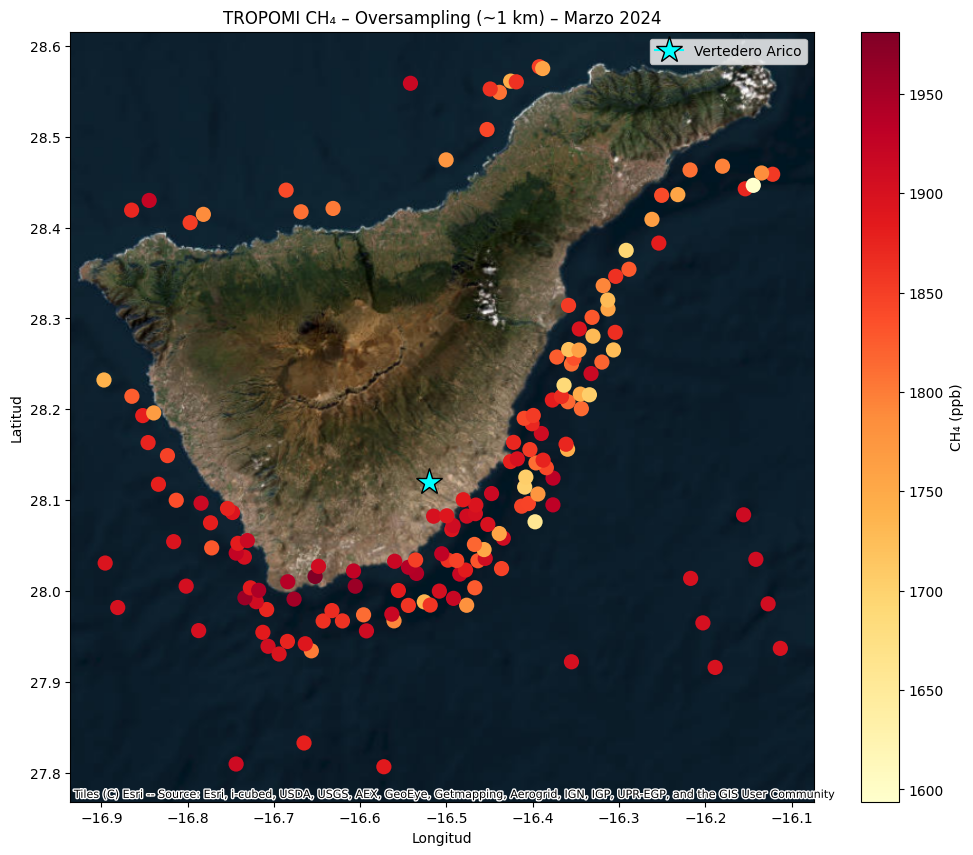

💾 Datos exportados


In [ ]:
# =========================================================
# 0. LIBRERÍAS
# =========================================================
!pip install pystac-client planetary-computer xarray h5netcdf contextily

import pystac_client
import planetary_computer
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import requests
import os
import warnings

warnings.filterwarnings("ignore")

# =========================================================
# 1. PARÁMETROS DEL ESTUDIO
# =========================================================

AOI = {
    "lon_min": -16.9,
    "lon_max": -16.1,
    "lat_min": 27.8,
    "lat_max": 28.6
}

VERTEDERO = (-16.52, 28.12)

FECHA_INICIO = "2024-03-01"
FECHA_FIN = "2024-03-31"

QA_THRESHOLD = 0.3   # puedes probar 0.2 también
GRID_RES = 0.01     # ~1 km

archivo_temp = "temp.nc"

# =========================================================
# 2. CONEXIÓN A PLANETARY COMPUTER
# =========================================================

print("🔌 Conectando a Planetary Computer...")

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    intersects={"type": "Point", "coordinates": VERTEDERO},
    datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
    query={
        "s5p:product_name": {"eq": "ch4"},
        "s5p:processing_mode": {"eq": "OFFL"}
    }
)

items = list(search.items())

print(f"📡 Pasadas encontradas: {len(items)}")

# =========================================================
# 3. DESCARGA + FILTRADO
# =========================================================

lista_datos = []

for i, item in enumerate(items):

    try:
        print(f"Procesando {i+1}/{len(items)}")

        url = planetary_computer.sign(item.assets["ch4"].href)

        r = requests.get(url, stream=True)
        with open(archivo_temp, "wb") as f:
            f.write(r.content)

        ds = xr.open_dataset(archivo_temp, group="PRODUCT", engine="h5netcdf")

        lat = ds.latitude.values[0]
        lon = ds.longitude.values[0]
        ch4 = ds.methane_mixing_ratio_bias_corrected.values[0]
        qa = ds.qa_value.values[0]

        # FILTRO ESPACIAL + CALIDAD
        mask = (
            (qa >= QA_THRESHOLD) &
            (lat > AOI["lat_min"]) & (lat < AOI["lat_max"]) &
            (lon > AOI["lon_min"]) & (lon < AOI["lon_max"])
        )

        df = pd.DataFrame({
            "lat": lat[mask],
            "lon": lon[mask],
            "ch4": ch4[mask]
        })

        if len(df) > 0:
            lista_datos.append(df)

        ds.close()
        os.remove(archivo_temp)

    except:
        print("⚠️ Error, saltando escena")

# =========================================================
# 4. UNIÓN DE DATOS
# =========================================================

if len(lista_datos) == 0:
    raise ValueError("No hay datos válidos")

df_all = pd.concat(lista_datos)

print(f"✅ Total puntos válidos: {len(df_all)}")

# =========================================================
# 5. OVERSAMPLING (CLAVE)
# =========================================================

print("🧠 Aplicando oversampling...")

lat_bins = np.arange(AOI["lat_min"], AOI["lat_max"], GRID_RES)
lon_bins = np.arange(AOI["lon_min"], AOI["lon_max"], GRID_RES)

df_all["lat_bin"] = np.digitize(df_all["lat"], lat_bins)
df_all["lon_bin"] = np.digitize(df_all["lon"], lon_bins)

grid = df_all.groupby(["lat_bin", "lon_bin"]).agg({
    "ch4": "mean",
    "lat": "mean",
    "lon": "mean"
}).reset_index()

print(f"🟧 Celdas con datos: {len(grid)}")

# =========================================================
# 6. VISUALIZACIÓN CIENTÍFICA
# =========================================================

fig, ax = plt.subplots(figsize=(12, 10))

sc = ax.scatter(
    grid["lon"], grid["lat"],
    c=grid["ch4"],
    cmap="YlOrRd",
    s=120,
    edgecolor="none"
)

# vertedero
ax.plot(
    VERTEDERO[0], VERTEDERO[1],
    marker="*",
    color="cyan",
    markersize=20,
    markeredgecolor="black",
    label="Vertedero Arico"
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery)

plt.colorbar(sc, label="CH₄ (ppb)")
plt.title("TROPOMI CH₄ – Oversampling (~1 km) – Marzo 2024")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

plt.show()

# =========================================================
# 7. EXPORTAR RESULTADOS (IMPORTANTE PARA GITHUB)
# =========================================================

grid.to_csv("ch4_oversampling_arico_mar2024.csv", index=False)

print("💾 Datos exportados")

    
*  Descarga TROPOMI L2 CH₄
*  Aplica filtro de calidad (qa_value>0.3)
*  Recorta AOI
*  Aplicar oversampling (1 km aprox)
*  Generar mapa científico
*  Exportar datos reproducibles

Los datos TROPOMI muestran una mayor densidad de observaciones válidas sobre el océano en comparación con la superficie terrestre, debido a la mayor calidad de señal (qa_value) en condiciones de baja heterogeneidad superficial. Esto limita la detección directa de emisiones puntuales en el vertedero de Arico. Se aplicó una técnica de oversampling sobre una malla de ~1 km para mejorar la representación espacial de los datos TROPOMI (resolución nativa ~7 km), sin aumentar la resolución real del sensor.


Se han procesado datos del producto TROPOMI L2 de metano (CH₄) correspondientes a marzo de 2024 sobre el área de interés centrada en el Complejo Ambiental de Arico (Tenerife). Tras la descarga desde el repositorio del Planetary Computer, se aplicó un filtrado de calidad utilizando el parámetro qa_value (umbral ≥ 0.3) junto con un recorte espacial sobre la zona de estudio. Dado que la resolución nativa del sensor (~7 km) es insuficiente para analizar fuentes puntuales, se implementó una técnica de oversampling, consistente en proyectar todas las observaciones válidas sobre una malla regular de aproximadamente 1 km de resolución y calcular promedios espaciales en cada celda. Este procedimiento permite mejorar la representatividad espacial y reducir el ruido asociado a mediciones individuales, sin aumentar la resolución real del instrumento. Como resultado, se obtiene un mapa agregado de concentraciones de CH₄ más robusto, adecuado para el análisis de patrones regionales y como base para etapas posteriores del estudio, como la detección de anomalías y la estimación de flujos de emisión.


# A VER SI CON FILTRO DE NUBES HACE ALGO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 6.6 MB/s eta 0:00:00
🔌 Conectando a Planetary Computer...
📡 Pasadas encontradas: 35
Procesando 1/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 2/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 3/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 4/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 5/35
⚠️ Error, saltando escena
Procesando 6/35
⚠️ Error, saltando escena
Procesando 7/35
⚠️ Error, saltando escena
Procesando 8/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 9/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 10/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 11/35
⚠️ No se encontró variable de nubes, se omite filtro de nubes
Procesando 12/35
⚠️ No se e

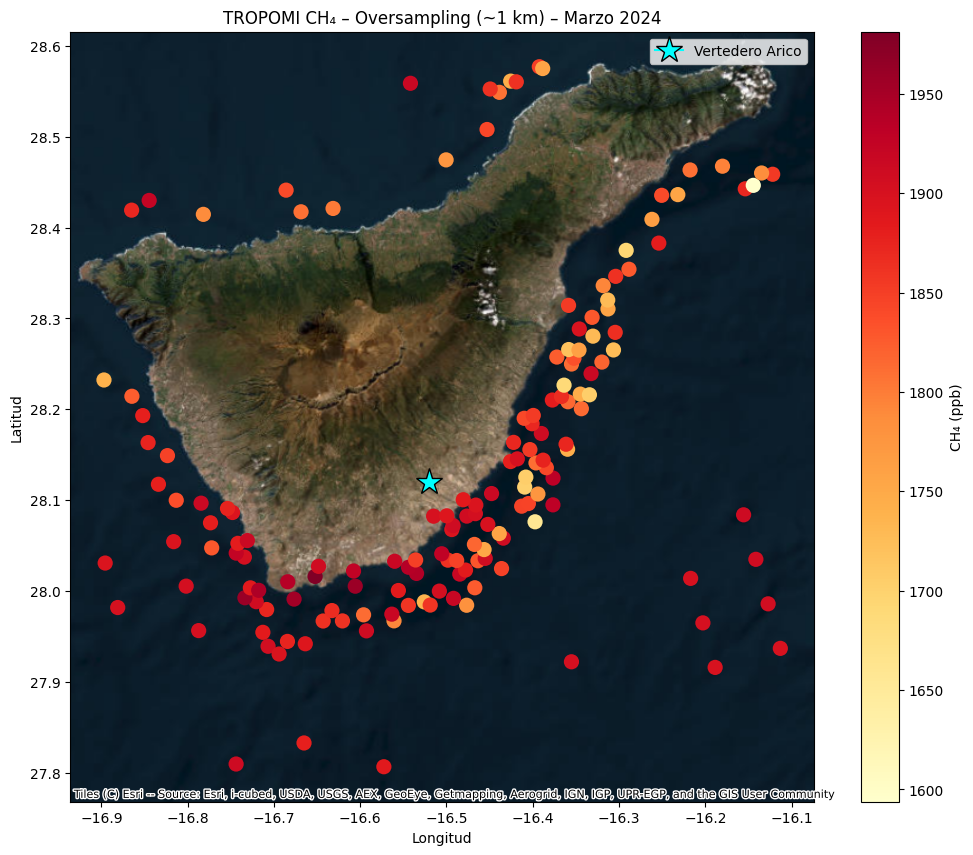

💾 Datos exportados


In [ ]:
# =========================================================
# 0. LIBRERÍAS
# =========================================================
!pip install pystac-client planetary-computer xarray h5netcdf contextily

import pystac_client
import planetary_computer
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import requests
import os
import warnings

warnings.filterwarnings("ignore")

# =========================================================
# 1. PARÁMETROS DEL ESTUDIO
# =========================================================

AOI = {
    "lon_min": -16.9,
    "lon_max": -16.1,
    "lat_min": 27.8,
    "lat_max": 28.6
}

VERTEDERO = (-16.52, 28.12)

FECHA_INICIO = "2024-03-01"
FECHA_FIN = "2024-03-31"

QA_THRESHOLD = 0.3
CLOUD_THRESHOLD = 0.3   # descarta píxeles con >30% nubes
GRID_RES = 0.01         # ~1 km

archivo_temp = "temp.nc"

# =========================================================
# 2. CONEXIÓN A PLANETARY COMPUTER
# =========================================================

print("🔌 Conectando a Planetary Computer...")

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    intersects={"type": "Point", "coordinates": VERTEDERO},
    datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
    query={
        "s5p:product_name": {"eq": "ch4"},
        "s5p:processing_mode": {"eq": "OFFL"}
    }
)

items = list(search.items())

print(f"📡 Pasadas encontradas: {len(items)}")

# =========================================================
# 3. DESCARGA + FILTRADO (QA + NUBES + AOI)
# =========================================================

lista_datos = []

for i, item in enumerate(items):

    try:
        print(f"Procesando {i+1}/{len(items)}")

        url = planetary_computer.sign(item.assets["ch4"].href)

        r = requests.get(url, stream=True)
        with open(archivo_temp, "wb") as f:
            f.write(r.content)

        ds = xr.open_dataset(archivo_temp, group="PRODUCT", engine="h5netcdf")

        lat = ds.latitude.values[0]
        lon = ds.longitude.values[0]
        ch4 = ds.methane_mixing_ratio_bias_corrected.values[0]
        qa = ds.qa_value.values[0]

        # Algunos productos tienen cloud_fraction
        if "cloud_fraction" in ds.variables:
            cloud = ds.cloud_fraction.values[0]
            print("✅ Variable de nubes encontrada: cloud_fraction")
        else:
            cloud = np.zeros_like(lat)
            print("⚠️ No se encontró variable de nubes, se omite filtro de nubes")

        # FILTRO ESPACIAL + CALIDAD + NUBES
        mask = (
            (qa >= QA_THRESHOLD) &
            (cloud <= CLOUD_THRESHOLD) &
            (lat > AOI["lat_min"]) & (lat < AOI["lat_max"]) &
            (lon > AOI["lon_min"]) & (lon < AOI["lon_max"])
        )

        df = pd.DataFrame({
            "lat": lat[mask],
            "lon": lon[mask],
            "ch4": ch4[mask]
        })

        if len(df) > 0:
            lista_datos.append(df)

        ds.close()
        os.remove(archivo_temp)

    except:
        print("⚠️ Error, saltando escena")

# =========================================================
# 4. UNIÓN DE DATOS
# =========================================================

if len(lista_datos) == 0:
    raise ValueError("No hay datos válidos")

df_all = pd.concat(lista_datos)
print(f"✅ Total puntos válidos: {len(df_all)}")

# =========================================================
# 5. OVERSAMPLING (~1 km)
# =========================================================

print("🧠 Aplicando oversampling...")

lat_bins = np.arange(AOI["lat_min"], AOI["lat_max"], GRID_RES)
lon_bins = np.arange(AOI["lon_min"], AOI["lon_max"], GRID_RES)

df_all["lat_bin"] = np.digitize(df_all["lat"], lat_bins)
df_all["lon_bin"] = np.digitize(df_all["lon"], lon_bins)

grid = df_all.groupby(["lat_bin", "lon_bin"]).agg({
    "ch4": "mean",
    "lat": "mean",
    "lon": "mean"
}).reset_index()

print(f"🟧 Celdas con datos: {len(grid)}")

# =========================================================
# 6. VISUALIZACIÓN
# =========================================================

fig, ax = plt.subplots(figsize=(12, 10))

sc = ax.scatter(
    grid["lon"], grid["lat"],
    c=grid["ch4"],
    cmap="YlOrRd",
    s=120,
    edgecolor="none"
)

# vertedero
ax.plot(
    VERTEDERO[0], VERTEDERO[1],
    marker="*",
    color="cyan",
    markersize=20,
    markeredgecolor="black",
    label="Vertedero Arico"
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery)

plt.colorbar(sc, label="CH₄ (ppb)")
plt.title("TROPOMI CH₄ – Oversampling (~1 km) – Marzo 2024")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

plt.show()

# =========================================================
# 7. EXPORTAR RESULTADOS
# =========================================================

grid.to_csv("ch4_oversampling_arico_mar2024.csv", index=False)
print("💾 Datos exportados")


In [ ]:
# =========================================================
# Mini script para inspeccionar variables de nubes en TROPOMI CH4 L2
# =========================================================


import pystac_client
import planetary_computer
import xarray as xr
import requests
import os

# =========================
# Parámetros de búsqueda
# =========================
VERTEDERO = (-16.52, 28.12)
FECHA_INICIO = "2024-03-01"
FECHA_FIN = "2024-03-31"

archivo_temp = "temp.nc"

# =========================
# Conexión a Planetary Computer
# =========================
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    intersects={"type": "Point", "coordinates": VERTEDERO},
    datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
    query={
        "s5p:product_name": {"eq": "ch4"},
        "s5p:processing_mode": {"eq": "OFFL"}
    }
)

items = list(search.items())
print(f"📡 Pasadas encontradas: {len(items)}")

# =========================
# Descargar el primer archivo válido
# =========================
for item in items:
    try:
        url = planetary_computer.sign(item.assets["ch4"].href)
        r = requests.get(url, stream=True)
        with open(archivo_temp, "wb") as f:
            f.write(r.content)
        print(f"✅ Archivo descargado: {archivo_temp}")
        break
    except:
        print("⚠️ Error descargando archivo, probando siguiente...")

# =========================
# Abrir con xarray y mostrar variables
# =========================
ds = xr.open_dataset(archivo_temp, group="PRODUCT", engine="h5netcdf")

print("\nVariables disponibles en el dataset:")
print(list(ds.variables))

# Buscar automáticamente variables relacionadas con nubes
nubes = [v for v in ds.variables if "cloud" in v.lower()]
if nubes:
    print("\nVariables relacionadas con nubes encontradas:")
    for v in nubes:
        print(f" - {v}")
else:
    print("\n⚠️ No se encontró ninguna variable de nubes en este archivo.")

# =========================
# Limpiar archivo temporal
# =========================
ds.close()
os.remove(archivo_temp)

📡 Pasadas encontradas: 35
✅ Archivo descargado: temp.nc

Variables disponibles en el dataset:
['delta_time', 'time_utc', 'qa_value', 'methane_mixing_ratio', 'methane_mixing_ratio_precision', 'methane_mixing_ratio_bias_corrected', 'scanline', 'ground_pixel', 'time', 'corner', 'layer', 'level', 'latitude', 'longitude']

⚠️ No se encontró ninguna variable de nubes en este archivo.


# NO HAY VARIABLE D ENUBES